# Домашнее задание к занятию "Улучшение качества обучения нейросети"

## Задание

На примере датасета персонажей мультфильма Симпсонов:

1. Модифицируйте код обучения, используя различные типы LR Schedulers из Pytorch. Проведите минимум 2 эксперимента с разными шедулерами.
1. Подберите аугментации **train** данных, при которых итоговое качество на валидации станет сильно **хуже**, чем полученное на занятии.
1. Возьмите любую архитектуру (VGG, EfficientNet или MobileNet) и примените к ней методы, которые разбирались на занятии.
1. Оформите вывод по результатам проведённых экспериментов.

In [1]:
import os
import time
import glob
import kaggle
from collections import Counter
import pandas as pd
from pathlib import Path

from tqdm.notebook import tqdm
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
import torch.nn.functional as F
from torchsummary import summary
import torchvision
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import Subset

from IPython.display import clear_output

## Загрузка и подготовка данных

### Загрузка данных с Kaggle

In [60]:
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    "alexattia/the-simpsons-characters-dataset",
    path='datas/simpsons',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset


>**Внимание!** После распаковки архива по какой-то неведомой мне причине внутри папки `sympsons_dataset` создается ее дубль

### Подготовка датасетов

Трансформация данных

In [61]:
input_size = 224

train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ColorJitter(0.9, 0.9, 0.9),
    transforms.RandomAffine(5),
    transforms.ToTensor(),
])


val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

Датасеты

In [ ]:
data_dir = "datas/simpsons/simpsons_dataset"

full_dataset = datasets.ImageFolder(root=data_dir)
indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.3, 
    stratify=full_dataset.targets,
    random_state=42
)

train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

print(f"Тренировочный сет: {len(train_dataset)} картинок")
print(f"Валидационный сет: {len(val_dataset)} картинок")

Тренировочный сет: 14653 картинок
Валидационный сет: 6280 картинок


EDA

In [66]:
print(f"Найдено классов: {len(full_dataset.classes)}")
print(f"Первые 5 классов: {full_dataset.classes[:5]}")

Найдено классов: 42
Первые 5 классов: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


             name  count
15  homer_simpson   2246
28   ned_flanders   1454
27    moe_szyslak   1452
20   lisa_simpson   1354
4    bart_simpson   1342


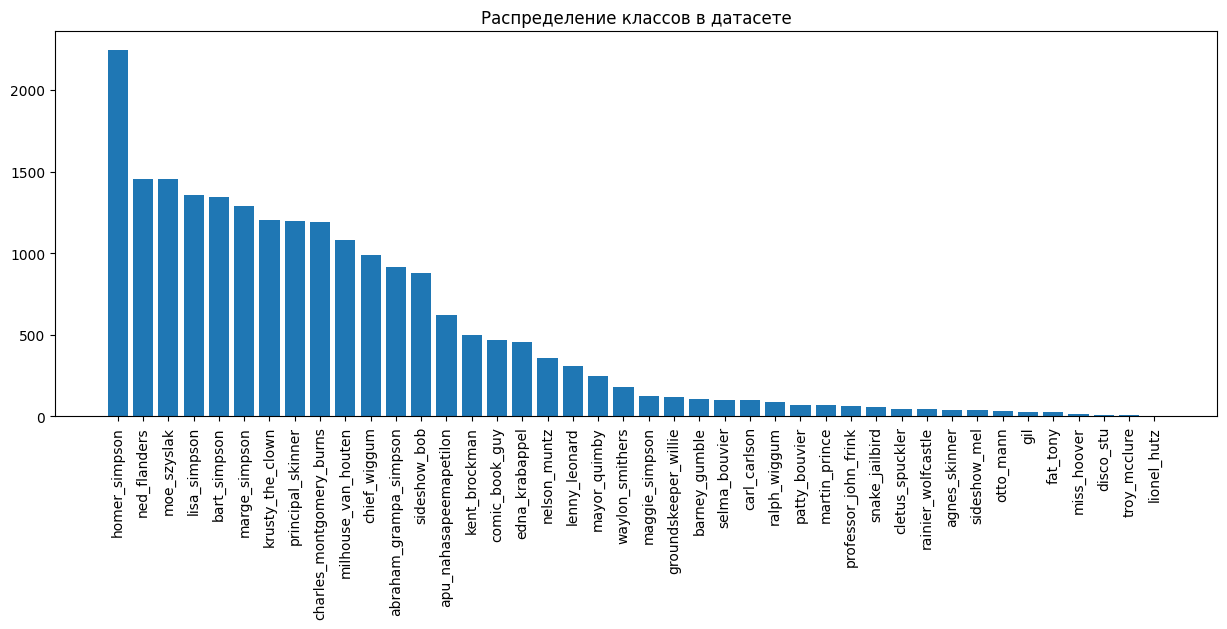

In [ ]:
count_dict = Counter([label for _, label in full_dataset.samples])

data = [
    {'name': full_dataset.classes[idx], 'count': count} 
    for idx, count in count_dict.items()
]
df = pd.DataFrame(data).sort_values('count', ascending=False)

print(df.head())

plt.figure(figsize=(15, 5))
plt.bar(df['name'], df['count'])
plt.xticks(rotation=90)
plt.title('Распределение классов в датасете')
plt.show()

## Вспомогательные функции

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
def plot_learning_curves(history):
    '''
    Функция для вывода графиков лосса, метрики и LR во время обучения.
    '''
    fig = plt.figure(figsize=(24, 7)) # Увеличил ширину для трех графиков

    # График Лосса
    plt.subplot(1, 3, 1)
    plt.title('Лосс', fontsize=15)
    plt.plot(history['loss']['train'], label='train', marker='o')
    plt.plot(history['loss']['val'], label='val', marker='o')
    plt.ylabel('лосс', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()
    plt.grid(True)

    # График Точности
    plt.subplot(1, 3, 2)
    plt.title('Точность', fontsize=15)
    plt.plot(history['acc']['train'], label='train', marker='o')
    plt.plot(history['acc']['val'], label='val', marker='o')
    plt.ylabel('accuracy', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.legend()
    plt.grid(True)

    # График Learning Rate
    plt.subplot(1, 3, 3)
    plt.title('Learning Rate', fontsize=15)
    plt.plot(history['lr'], label='lr', color='green', marker='o')
    plt.ylabel('LR', fontsize=15)
    plt.xlabel('эпоха', fontsize=15)
    plt.yscale('log') # Логарифмическая шкала
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
# def plot_learning_curves(history):
#     '''
#     Функция для вывода графиков лосса и метрики во время обучения.
#     '''
#     fig = plt.figure(figsize=(20, 7))

#     plt.subplot(1,2,1)
#     plt.title('Лосс', fontsize=15)
#     plt.plot(history['loss']['train'], label='train')
#     plt.plot(history['loss']['val'], label='val')
#     plt.ylabel('лосс', fontsize=15)
#     plt.xlabel('эпоха', fontsize=15)
#     plt.legend()

#     plt.subplot(1,2,2)
#     plt.title('Точность', fontsize=15)
#     plt.plot(history['acc']['train'], label='train')
#     plt.plot(history['acc']['val'], label='val')
#     plt.ylabel('accuracy', fontsize=15)
#     plt.xlabel('эпоха', fontsize=15)
#     plt.legend()
#     plt.show()

In [4]:
def train(
    model, 
    criterion,
    optimizer, 
    train_batch_gen,
    val_batch_gen,
    num_epochs=10
):
    '''
    Функция для обучения модели и вывода лосса и метрики во время обучения.
    '''

    history = defaultdict(lambda: defaultdict(list))
    history['lr'] = []

    for epoch in range(num_epochs):
        train_loss = 0
        train_acc = 0
        val_loss = 0
        val_acc = 0
        
        start_time = time.time()

        # устанавливаем поведение dropout / batch_norm  в обучение
        model.train(True) 

        # на каждой "эпохе" делаем полный проход по данным
        for X_batch, y_batch in train_batch_gen:
            # обучаемся на текущем батче
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            
            loss = criterion(logits, y_batch.long().to(device))

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            train_loss += np.sum(loss.detach().cpu().numpy())
            y_pred = logits.max(1)[1].detach().cpu().numpy()
            train_acc += np.mean(y_batch.cpu().numpy() == y_pred)

        # подсчитываем лоссы и сохраням в "историю"
        train_loss /= len(train_batch_gen)
        train_acc /= len(train_batch_gen) 
        history['loss']['train'].append(train_loss)
        history['acc']['train'].append(train_acc)
    
        # устанавливаем поведение dropout / batch_norm в режим тестирования
        model.train(False) 

        # полностью проходим по валидационному датасету  
        for X_batch, y_batch in val_batch_gen:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch.long().to(device))
            val_loss += np.sum(loss.detach().cpu().numpy())
            y_pred = logits.max(1)[1].detach().cpu().numpy()
            val_acc += np.mean(y_batch.cpu().numpy() == y_pred)

        # подсчитываем лоссы и сохраням в "историю"
        val_loss /= len(val_batch_gen)
        val_acc /= len(val_batch_gen)
        current_lr = optimizer.param_groups[0]['lr'] 
        history['loss']['val'].append(val_loss)
        history['acc']['val'].append(val_acc)
        history['lr'].append(current_lr)
        
        clear_output()

        # печатаем результаты после каждой эпохи
        print("Epoch {} of {} took {:.3f}s".format(
            epoch + 1, num_epochs, time.time() - start_time))
        print("Current LR:", current_lr)
        print("  training loss (in-iteration): \t{:.6f}".format(train_loss))
        print("  validation loss (in-iteration): \t{:.6f}".format(val_loss))
        print("  training accuracy: \t\t\t{:.2f} %".format(train_acc * 100))
        print("  validation accuracy: \t\t\t{:.2f} %".format(val_acc * 100))
        
        plot_learning_curves(history)
        # scheduler.step(val_loss) # ReduceLROnPlateau
        # scheduler.step()
        
    return model, history

## 1. LR Schedulers

In [93]:
BATCH_SIZE = 128 

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Проверим один батч
images, labels = next(iter(train_loader))
print(f"Форма тензора с картинками: {images.shape}")
print(f"Форма тензора с метками: {labels.shape}")

Форма тензора с картинками: torch.Size([128, 3, 224, 224])
Форма тензора с метками: torch.Size([128])


### 1.1 Обучение Resnet18 с нуля

Epoch 25 of 25 took 30.566s
Current LR: 0.001
  training loss (in-iteration): 	0.079325
  validation loss (in-iteration): 	0.724557
  training accuracy: 			97.73 %
  validation accuracy: 			84.42 %


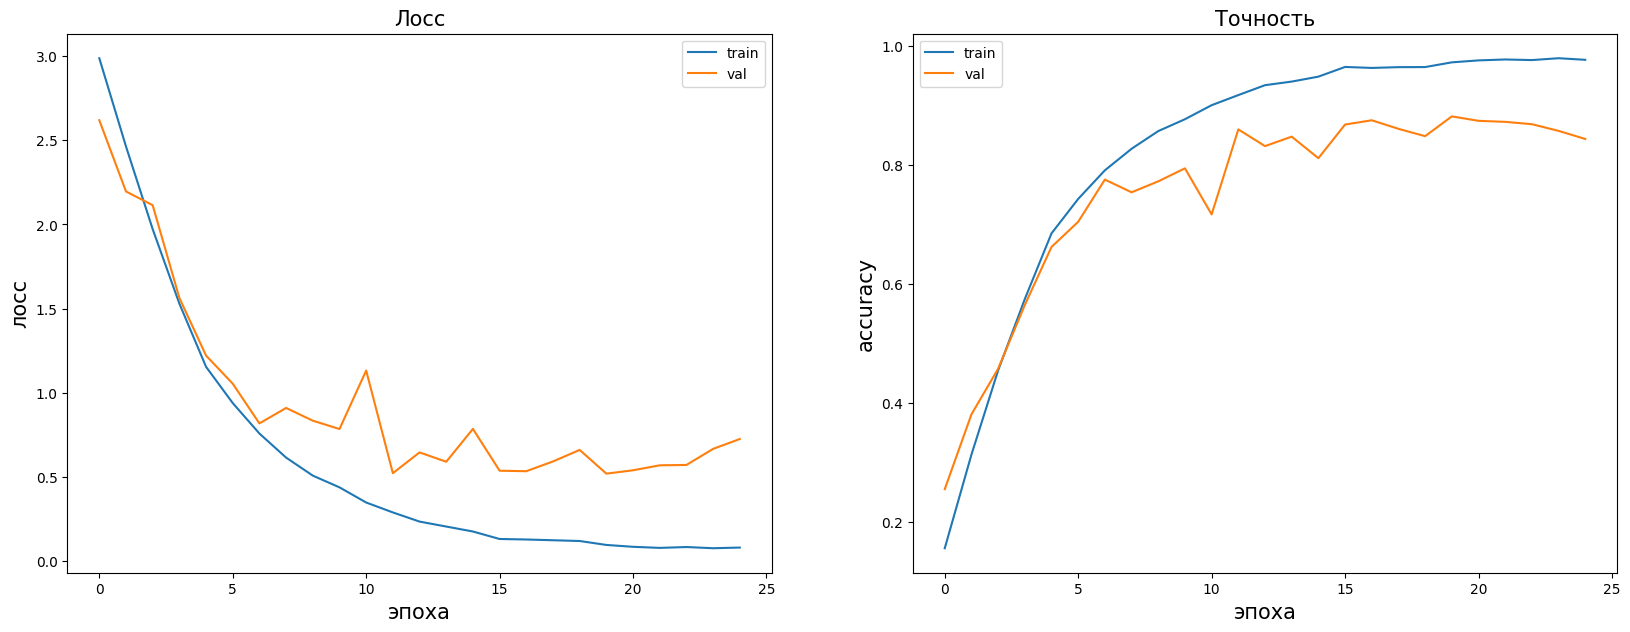

In [94]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

### 1.2 StepLR

Epoch 25 of 25 took 32.794s
Current LR: 1.0000000000000006e-11
  training loss (in-iteration): 	0.950641
  validation loss (in-iteration): 	0.890587
  training accuracy: 			74.38 %
  validation accuracy: 			76.34 %


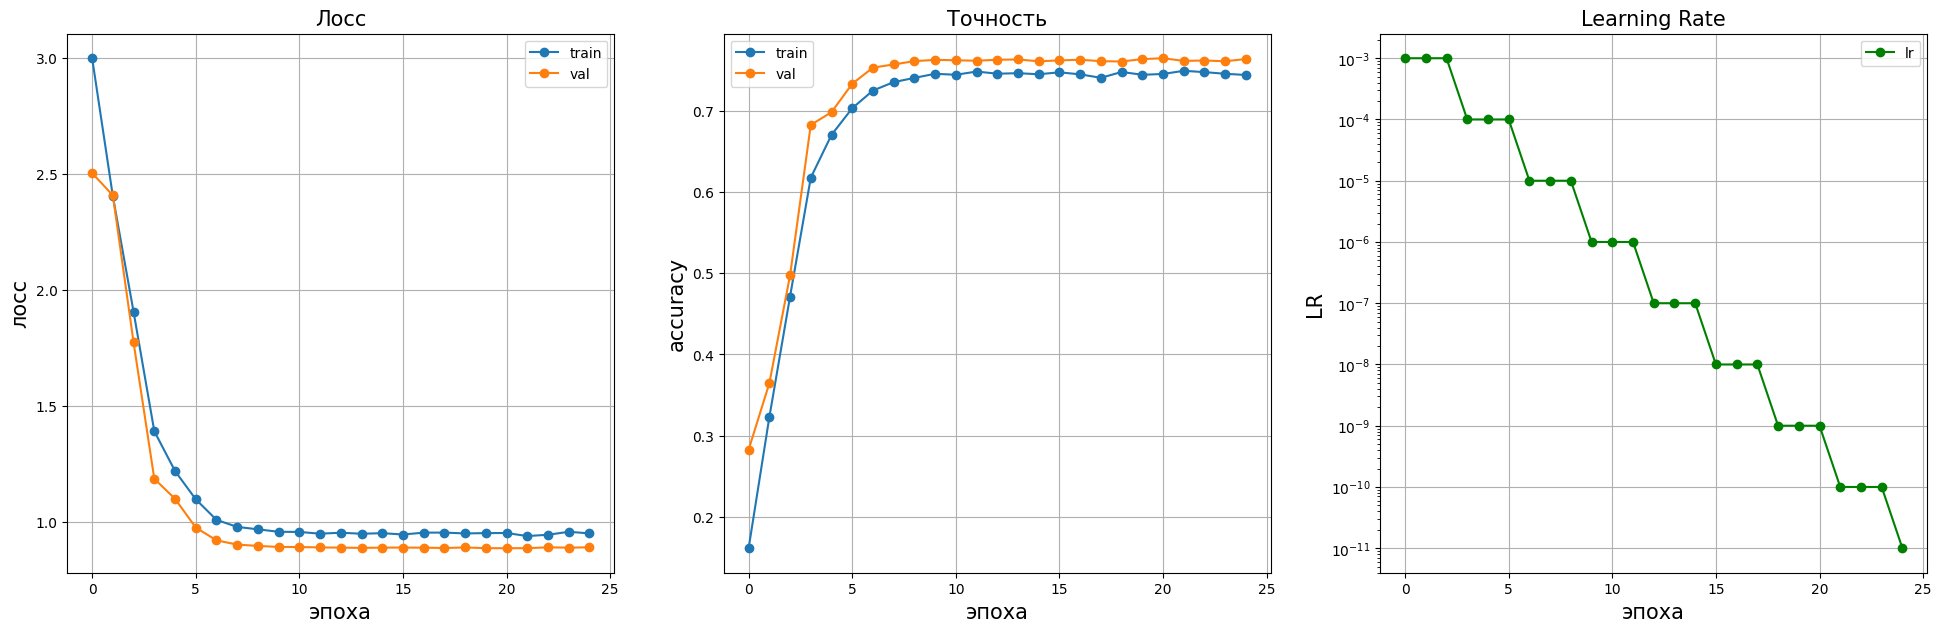

In [107]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

### 1.3 ReduceLROnPlateau

Epoch 25 of 25 took 32.797s
Current LR: 1e-05
  training loss (in-iteration): 	0.029023
  validation loss (in-iteration): 	0.320531
  training accuracy: 			99.41 %
  validation accuracy: 			92.33 %


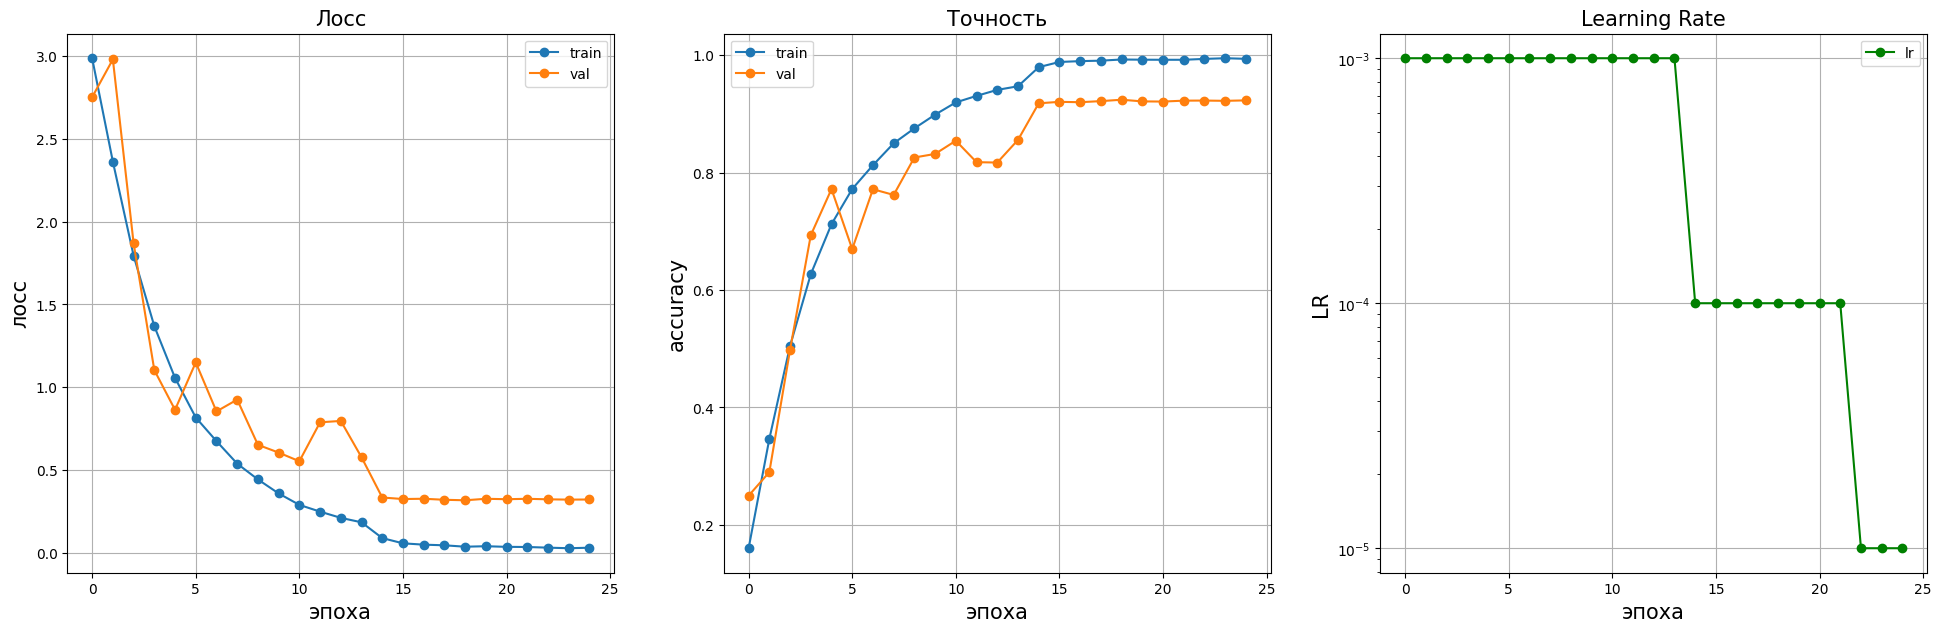

In [109]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

### 1.4 CosineAnnealingLR

Epoch 25 of 25 took 32.952s
Current LR: 0.0006545084971874768
  training loss (in-iteration): 	0.071850
  validation loss (in-iteration): 	0.505961
  training accuracy: 			98.10 %
  validation accuracy: 			88.23 %


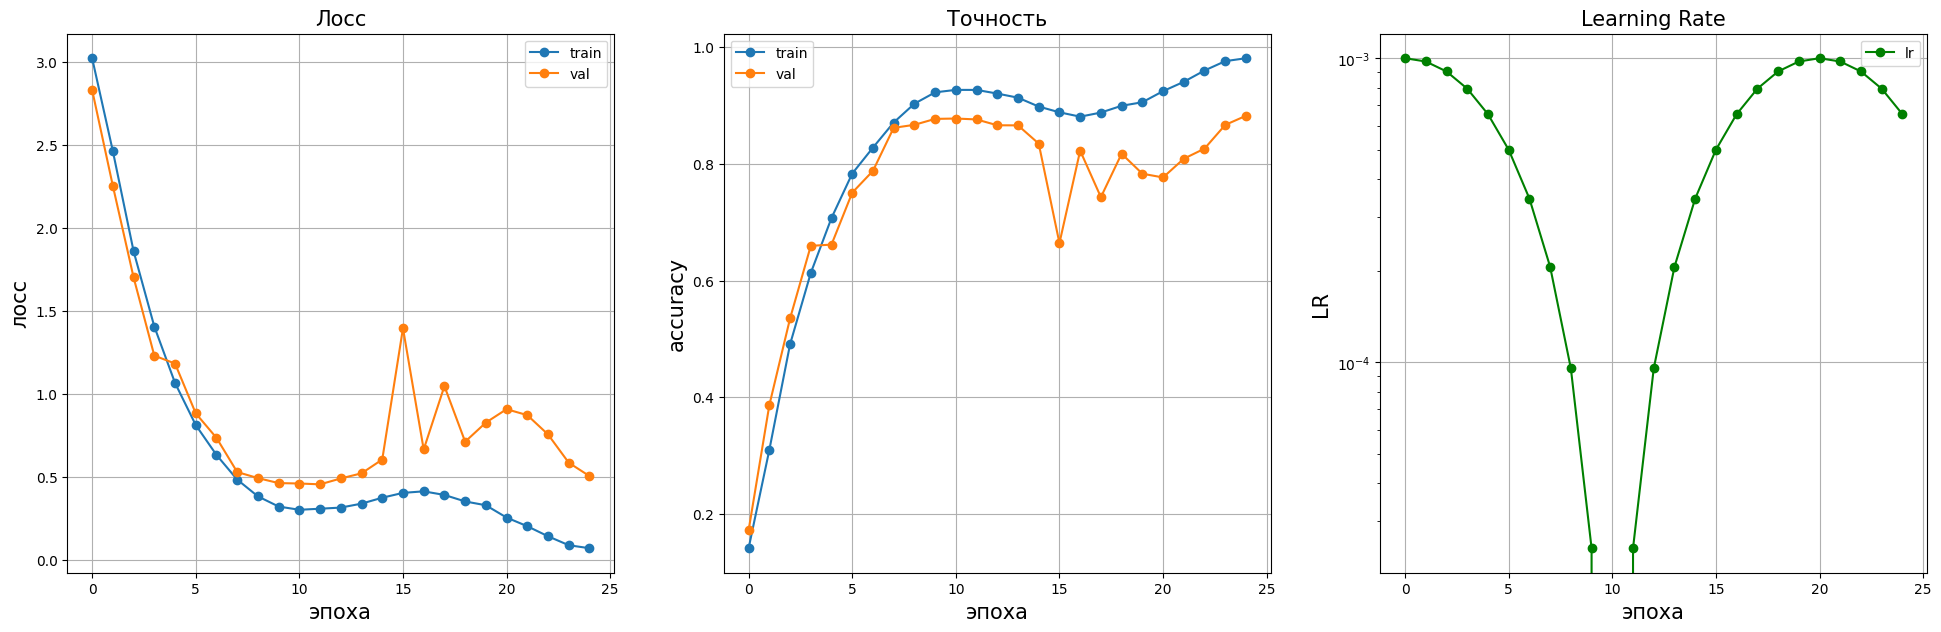

In [104]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

## 2. Аугментация

### 2.1 Пример, когда аугментация позволила улучщить результаты обучения модели

In [5]:
input_size = 224

train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.RandomRotation(degrees=45),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
    transforms.ColorJitter(0.9, 0.9, 0.9),
    transforms.RandomAffine(5),
    transforms.ToTensor(),
])


val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

In [6]:
data_dir = "datas/simpsons/simpsons_dataset"

full_dataset = datasets.ImageFolder(root=data_dir)
indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.3, 
    stratify=full_dataset.targets,
    random_state=42
)

train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

print(f"Тренировочный сет: {len(train_dataset)} картинок")
print(f"Валидационный сет: {len(val_dataset)} картинок")

Тренировочный сет: 14653 картинок
Валидационный сет: 6280 картинок


In [7]:
BATCH_SIZE = 128 

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Проверим один батч
images, labels = next(iter(train_loader))
print(f"Форма тензора с картинками: {images.shape}")
print(f"Форма тензора с метками: {labels.shape}")

Форма тензора с картинками: torch.Size([128, 3, 224, 224])
Форма тензора с метками: torch.Size([128])


Epoch 25 of 25 took 31.987s
Current LR: 0.001
  training loss (in-iteration): 	0.277529
  validation loss (in-iteration): 	0.347681
  training accuracy: 			92.05 %
  validation accuracy: 			90.39 %


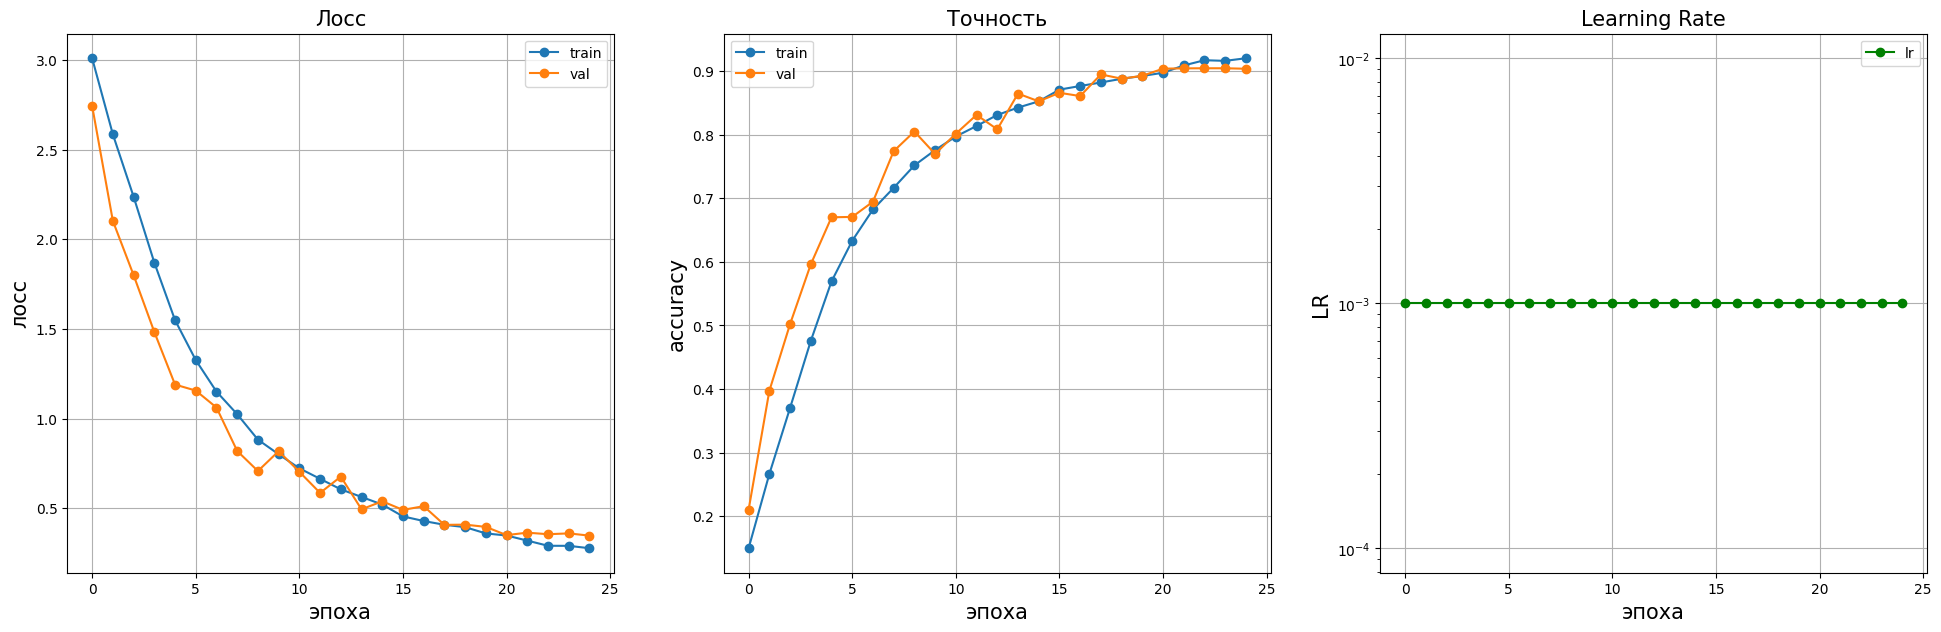

In [8]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

Добавление большого количества вариаций картинок в обучающей выборке позволило модели стать "умнее". Обучение проходило равномерно, отсутствуют какие-либо признаки переобучения. Accurscy на валидационной выборке улучшилось с 84.42% до 90.39%

### 2.2 Пример использования аугментации, в результате которого качество модели ухудшилось

In [9]:
input_size = 224

train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.RandomResizedCrop(224, scale=(0.01, 0.05)),
    transforms.ColorJitter(0.9, 0.9, 0.9),
    transforms.RandomAffine(5),
    transforms.ToTensor(),
])


val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

In [10]:
data_dir = "datas/simpsons/simpsons_dataset"

full_dataset = datasets.ImageFolder(root=data_dir)
indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.3, 
    stratify=full_dataset.targets,
    random_state=42
)

train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

print(f"Тренировочный сет: {len(train_dataset)} картинок")
print(f"Валидационный сет: {len(val_dataset)} картинок")

Тренировочный сет: 14653 картинок
Валидационный сет: 6280 картинок


In [11]:
BATCH_SIZE = 128 

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Проверим один батч
images, labels = next(iter(train_loader))
print(f"Форма тензора с картинками: {images.shape}")
print(f"Форма тензора с метками: {labels.shape}")

Форма тензора с картинками: torch.Size([128, 3, 224, 224])
Форма тензора с метками: torch.Size([128])


Epoch 25 of 25 took 31.517s
Current LR: 0.001
  training loss (in-iteration): 	2.944090
  validation loss (in-iteration): 	2.927894
  training accuracy: 			16.05 %
  validation accuracy: 			14.64 %


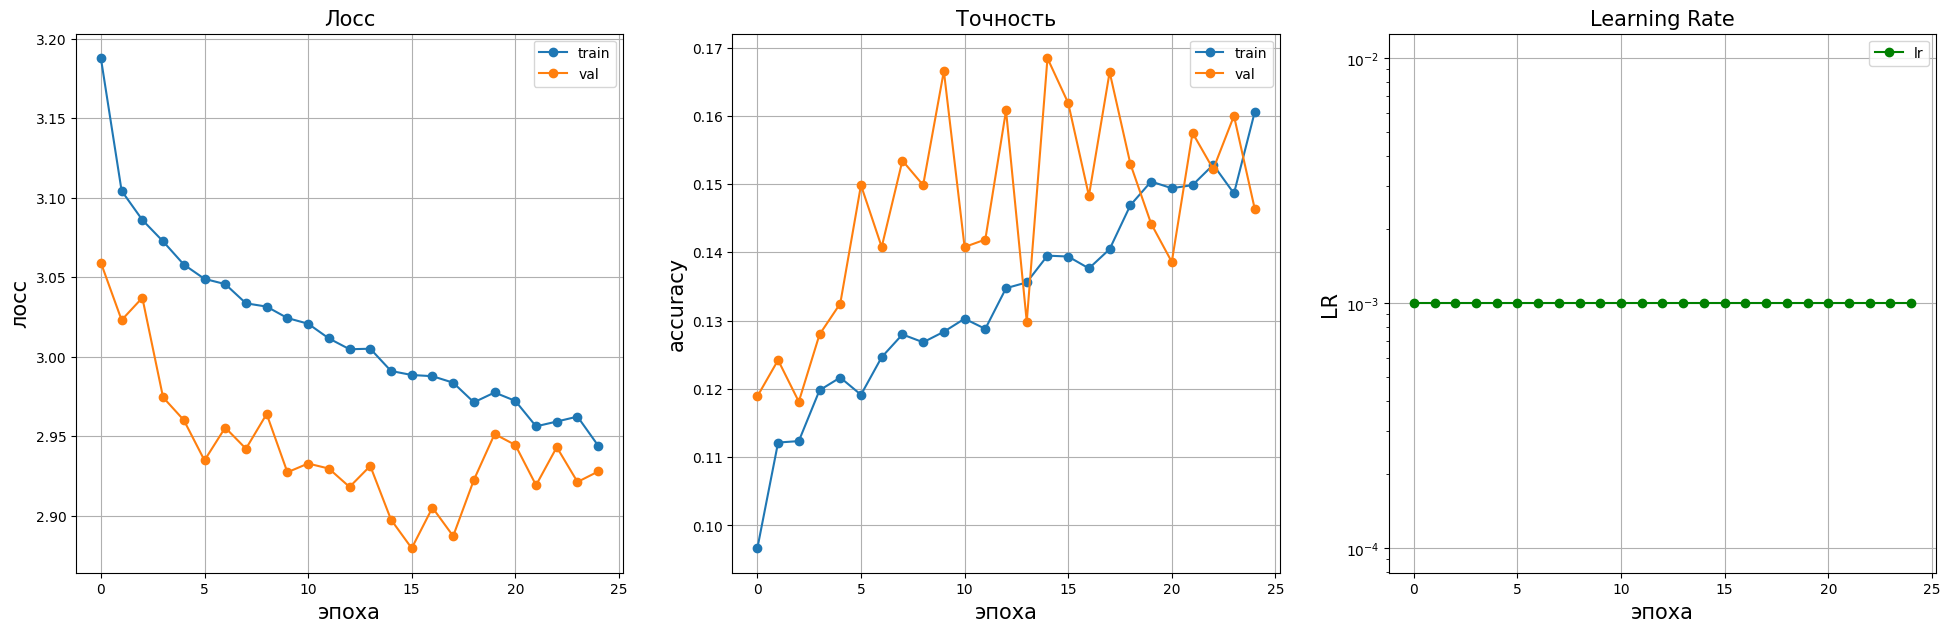

In [12]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

Это ужасно! Кроме того, что мы перевернули все картинки в обучающей выборке вверх ногами, мы еще представили для обучения модели лишь маленькие их фрагменты. Модель абсолютно ослепла и не смогла обучисться. На память пришла притча о том, как трое слепцов изучали слона.

## 3. MobileNet

### 3.1 Feature Extraction

In [17]:
input_size = 224

train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])


val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

In [18]:
data_dir = "datas/simpsons/simpsons_dataset"

full_dataset = datasets.ImageFolder(root=data_dir)
indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.3, 
    stratify=full_dataset.targets,
    random_state=42
)

train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

print(f"Тренировочный сет: {len(train_dataset)} картинок")
print(f"Валидационный сет: {len(val_dataset)} картинок")

Тренировочный сет: 14653 картинок
Валидационный сет: 6280 картинок


In [20]:
BATCH_SIZE = 128 

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Проверим один батч
images, labels = next(iter(train_loader))
print(f"Форма тензора с картинками: {images.shape}")
print(f"Форма тензора с метками: {labels.shape}")

Форма тензора с картинками: torch.Size([128, 3, 224, 224])
Форма тензора с метками: torch.Size([128])


In [28]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, 42) 
)

model = model.to(device)

In [29]:
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

Epoch 25 of 25 took 14.980s
Current LR: 0.001
  training loss (in-iteration): 	0.549412
  validation loss (in-iteration): 	0.717788
  training accuracy: 			84.22 %
  validation accuracy: 			80.44 %


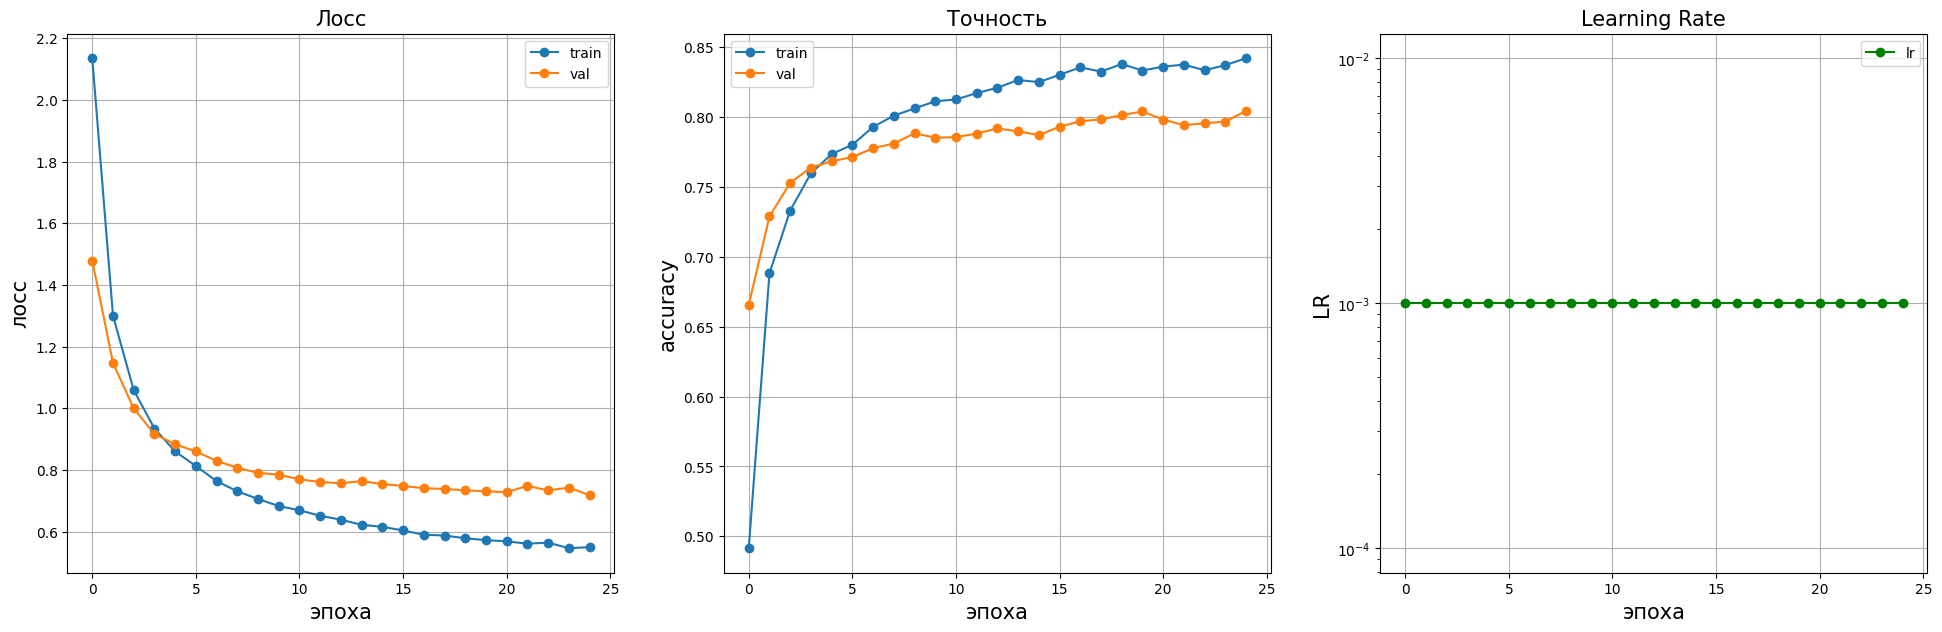

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=0.001
)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)

### 3.1 Fine-Tuning

In [30]:
model = models.mobilenet_v2(weights='DEFAULT')

for param in model.parameters():
    param.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 42)
)

# Будем обучать блоки с 14 по 19:
for i in range(14, 19):
    for param in model.features[i].parameters():
        param.requires_grad = True

model = model.to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

Epoch 25 of 25 took 17.575s
Current LR: 0.0001
  training loss (in-iteration): 	0.002765
  validation loss (in-iteration): 	0.239651
  training accuracy: 			99.97 %
  validation accuracy: 			94.02 %


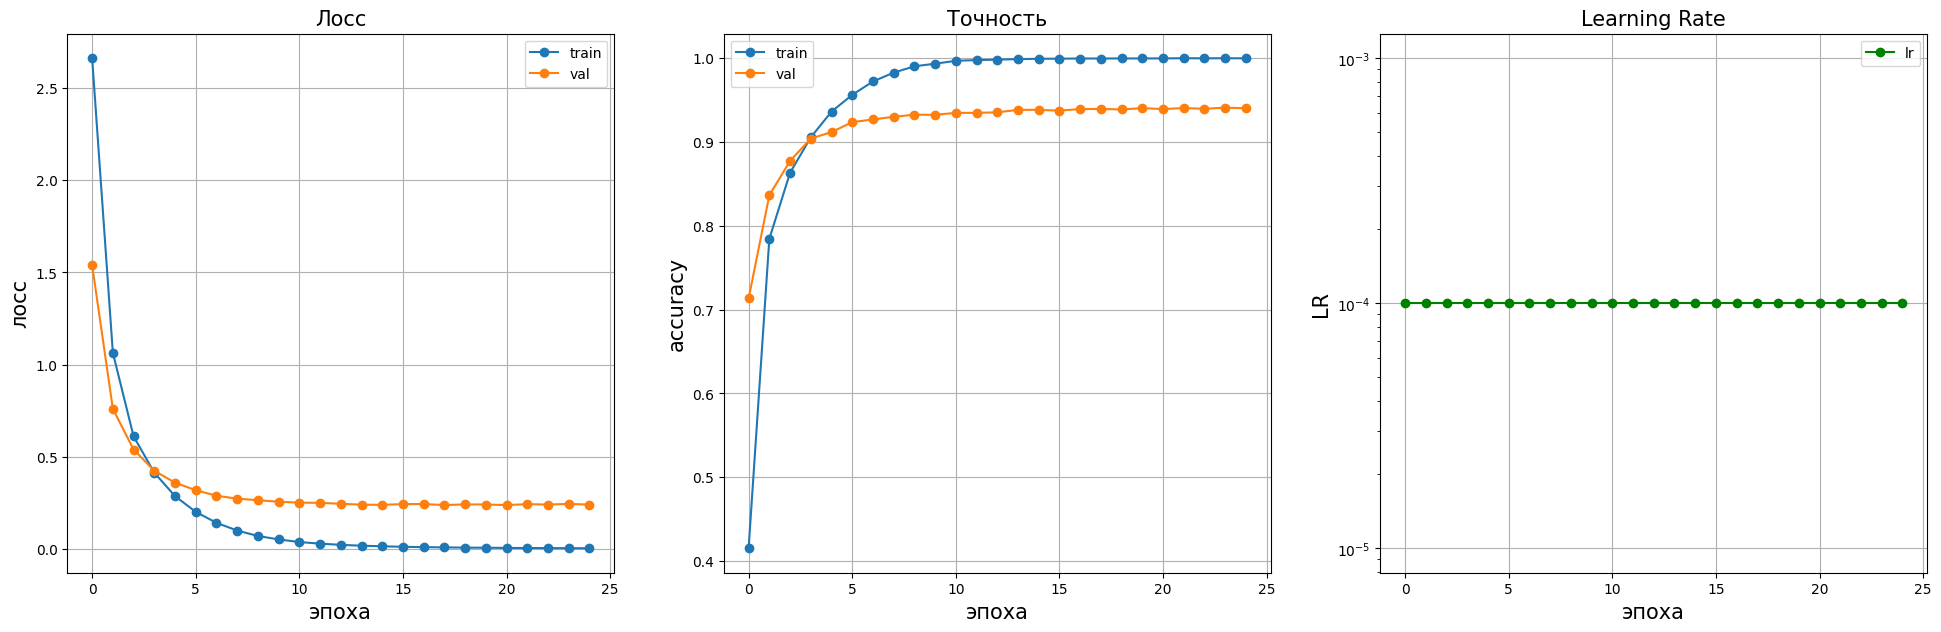

In [31]:
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params_to_update, lr=0.0001)
criterion = nn.CrossEntropyLoss()

clf_model, history = train(
    model=model,
    criterion=criterion,
    optimizer=optimizer, 
    train_batch_gen=train_loader,
    val_batch_gen=val_loader, 
    num_epochs=25
)


## 4. Выводы

1. Методы Learning Rate Schedule ReduceLROnPlateau и CosineAnnealingLR показали лучшие результаты по сравнению с StepLR.
    - ReduceLROnPlateau является адаптивным, он снижает LR только тогда, когда модель реально перестала улучшаться, это позволяет модели выжать максимум из текущего LRсли модель всё еще может учиться на 0.001, он не будет ей мешать. Как только прогресс замер («плато») — он дает маленький LR, чтобы проработать детали.
    - CosineAnnealingLR плавно меняет LR по кривой косинуса, нет резких прыжков. Плавное снижение помогает весам модели оседать в более «широких» минимумах. В нашем примере прид увеличении количества эпох результат мог бы быть лучше.

1. Использование аугментации должно быть продиктовано здравым смыслом. Если в результате изменений появляются экземпляры, которые не соответствуют примерам из реальных условий, то модель будет обучаться плохо. В нашем примере модель абсолютно ослепла и не смогла обучисться по аналогии с притчей о том, как трое слепцов изучали слона.

1. Дообучение нескольких последних слоев модели, которые отвечают за наиболее характерные черты картинок, позволило улучшить качество использования предобученной модели с 80.44% Feature Extraction до 94.02% Fine-Tuning.